In [1]:
import os
# Force CPU backend on Apple Silicon to avoid Metal issues
os.environ['JAX_PLATFORMS'] = 'cpu'

import matplotlib.pyplot as plt

# Disable LaTeX rendering in matplotlib
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "sans-serif"

from jax import random
from jax import numpy as jnp
from sbijax import plot_loss_profile
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_utils_jax import plot_real_synth_hist, extract_samples
# from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.enhanced_stats_37 import FEATURE_NAMES

In [6]:
import pickle
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM_JAX, create_prior
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_inference_jax import infer_parameters_snle
from sbijax import NLE
from sbijax.nn import make_maf

# Load saved parameters 
model_name = 'snle_2M_h128_l8_b256_37feat.pkl'# 'snle_2M_h128_l8_b256_1feat' #''snle_2M_h128_l8_b1024_300feat' # 'snle_2M_h128_l8_b2048_300feat' #'snle_5M_h128_l8_b256_37feat' #'snle_2M_h64_l5_b256_37feat'
model_name = 'snle_2M_lr0.0001_ts2000_h128_l8_b256_37feat/model.pkl'
model_name = 'snle_2M_lr0.0005_ts2000_h128_l8_b256_37feat_0/model'
with open(f'/Users/laura.driscoll/Documents/code/sbi_results/{model_name}.pkl', 'rb') as f:
    saved_data = pickle.load(f)

# Reconstruct the model
simulator = PatchForagingDDM_JAX(
    max_sites_per_window=100,
    interval_normalization=saved_data['config']['interval_normalization']
)
prior_fn = create_prior(
    prior_low=jnp.array(saved_data['config']['prior_low']),
    prior_high=jnp.array(saved_data['config']['prior_high'])
)

rng_key = random.PRNGKey(saved_data['config']['seed']+1)
rng_key, test_key = random.split(rng_key)
test_theta = prior_fn().sample(seed=test_key)
test_x = simulator.simulator_fn(seed=test_key, theta=test_theta)
n_features = test_x.shape[-1]

# Rebuild the flow architecture (must match training)
flow = make_maf(
    n_dimension=n_features,  # obs data dimension
    n_layers=saved_data['config']['num_layers'],
    hidden_sizes=(saved_data['config']['hidden_dim'], saved_data['config']['hidden_dim'])
)

# Create SNLE model
fns = prior_fn, simulator.simulator_fn
snle = NLE(fns, flow)

print("Model reconstructed! Ready for inference.")

Model reconstructed! Ready for inference.


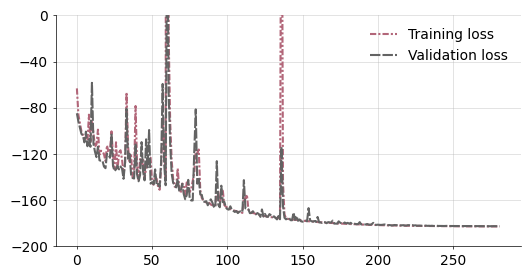

In [8]:
# Disable LaTeX rendering in matplotlib
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "sans-serif"

_, axes = plt.subplots(figsize=(6, 3))
plot_loss_profile(saved_data['losses'], axes)
axes.set_ylim(bottom=-200,top=0)
plt.show()


2. Simulating observed data...
   True theta: [0.         1.4177878  0.46107054 0.40637797]

3. Testing inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 4950, 4)
Posterior samples shape (flattened): (9900, 4)
   True theta: [0.5        1.4177878  0.46107054 0.40637797]

3. Testing inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 4950, 4)
Posterior samples shape (flattened): (9900, 4)
   True theta: [1.         1.4177878  0.46107054 0.40637797]

3. Testing inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 4950, 4)
Posterior samples shape (flattened): (9900, 4)
   True theta: [1.5        1.4177878  0.46107054 0.40637797]

3. Testing inference.

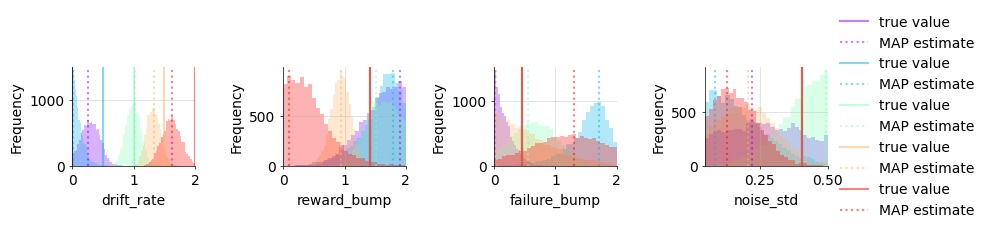

In [9]:
param_names = ["drift_rate", "reward_bump", "failure_bump", "noise_std"]
param_labels = [
    "drift_rate: evidence accumulation rate",
    "reward_bump: evidence boost from receiving reward",
    "failure_bump: evidence boost from not receiving reward",
    "noise_std: std of noise in evidence accumulation"
]

number_of_samples = 5
cmap = mpl.colormaps['rainbow']

# 3. Sample the colormap at regular intervals from 0 to 1
# This returns an array of RGBA tuples
gradient = np.linspace(0, 1, number_of_samples)
colors_rgba = cmap(gradient)
drift_values = np.linspace(0, 1, number_of_samples)*2

fig, axes = plt.subplots(1, 4, figsize=(10, 2))
axes = axes.flatten()

# --- Simulate observed data ---
print("\n2. Simulating observed data...")
rng_key = random.PRNGKey(88)
rng_key, subkey = random.split(rng_key)
true_theta = prior_fn().sample(seed=subkey)['theta']

for drift_i, drift in enumerate(drift_values):
    true_theta = true_theta.at[0].set(drift)
    rng_key, subkey = random.split(rng_key)
    _, observed_stats = simulator.simulate_one_window(true_theta, subkey)
    print(f"   True theta: {true_theta}")

    # --- Run inference ---
    print("\n3. Testing inference...")
    rng_key, subkey = random.split(rng_key)
    posterior_samples, diagnostics = infer_parameters_snle(
    snle,
    saved_data['snle_params'],
    observed_stats, 
    saved_data['y_mean'], saved_data['y_std'],
    num_samples=5_000,
    num_warmup=50,
    num_chains=2,
    rng_key=subkey
    )

    # --- Plot posterior distributions ---
    for i in range(4):

        # Compute histogram
        counts, bins, _ =axes[i].hist(posterior_samples[:, i], bins=30, color=colors_rgba[drift_i], edgecolor=None, alpha=0.3)

        # Posterior mode (bin center with max count)
        mode_index = jnp.argmax(counts)
        posterior_mode = (bins[mode_index] + bins[mode_index + 1]) / 2

        axes[i].axvline(true_theta[i], color=colors_rgba[drift_i], linestyle='-', label="true value",alpha=0.5)
        axes[i].axvline(posterior_mode, color=colors_rgba[drift_i], linestyle=':', label='MAP estimate',alpha=0.5)

        axes[i].set_xlabel(param_names[i])
        axes[i].set_ylabel("Frequency")

        axes[i].set_xlim(saved_data['config']['prior_low'][i], saved_data['config']['prior_high'][i])

    axes[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()



2. Simulating observed data...
   True theta: [0.49158454 0.         0.62659407 0.21516795]

3. Testing inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 950, 4)
Posterior samples shape (flattened): (1900, 4)
   True theta: [0.49158454 0.5        0.62659407 0.21516795]

3. Testing inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 950, 4)
Posterior samples shape (flattened): (1900, 4)
   True theta: [0.49158454 1.         0.62659407 0.21516795]

3. Testing inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 950, 4)
Posterior samples shape (flattened): (1900, 4)
   True theta: [0.49158454 1.5        0.62659407 0.21516795]

3. Testing inference...


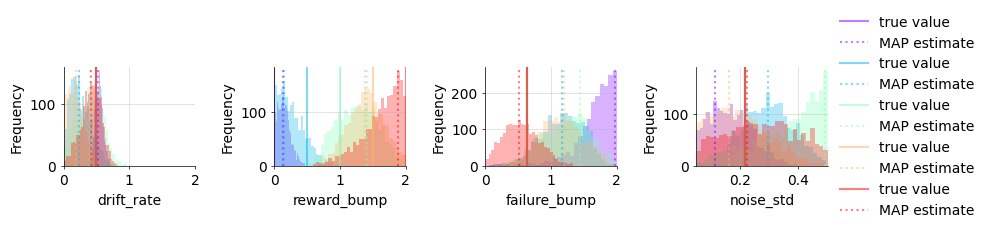

In [10]:
vary_theta = 1
param_names = ["drift_rate", "reward_bump", "failure_bump", "noise_std"]
param_labels = [
    "drift_rate: evidence accumulation rate",
    "reward_bump: evidence boost from receiving reward",
    "failure_bump: evidence boost from not receiving reward",
    "noise_std: std of noise in evidence accumulation"
]

number_of_samples = 5
cmap = mpl.colormaps['rainbow']

# 3. Sample the colormap at regular intervals from 0 to 1
# This returns an array of RGBA tuples
gradient = np.linspace(0, 1, number_of_samples)
colors_rgba = cmap(gradient)
theta_values = np.linspace(saved_data['config']['prior_low'][vary_theta], 
                           saved_data['config']['prior_high'][vary_theta], 
                           number_of_samples)

fig, axes = plt.subplots(1, 4, figsize=(10, 2))
axes = axes.flatten()

# --- Simulate observed data ---
print("\n2. Simulating observed data...")
rng_key = random.PRNGKey(111)
rng_key, subkey = random.split(rng_key)
true_theta = prior_fn().sample(seed=subkey)['theta']

for theta_i, theta in enumerate(theta_values):
    true_theta = true_theta.at[vary_theta].set(theta)
    rng_key, subkey = random.split(rng_key)
    _, observed_stats = simulator.simulate_one_window(true_theta, subkey)
    print(f"   True theta: {true_theta}")

    # --- Run inference ---
    print("\n3. Testing inference...")
    rng_key, subkey = random.split(rng_key)
    posterior_samples, diagnostics = infer_parameters_snle(
    snle,
    saved_data['snle_params'],
    observed_stats, 
    saved_data['y_mean'], saved_data['y_std'],
    num_samples=1000,
    num_warmup=50,
    num_chains=2,
    rng_key=subkey
    )

    # --- Plot posterior distributions ---
    for i in range(4):

        # Compute histogram
        counts, bins, _ =axes[i].hist(posterior_samples[:, i], bins=30, color=colors_rgba[theta_i], edgecolor=None, alpha=0.3)

        # Posterior mode (bin center with max count)
        mode_index = jnp.argmax(counts)
        posterior_mode = (bins[mode_index] + bins[mode_index + 1]) / 2

        axes[i].axvline(true_theta[i], color=colors_rgba[theta_i], linestyle='-', label="true value",alpha=0.5)
        axes[i].axvline(posterior_mode, color=colors_rgba[theta_i], linestyle=':', label='MAP estimate',alpha=0.5)

        axes[i].set_xlabel(param_names[i])
        axes[i].set_ylabel("Frequency")

        axes[i].set_xlim(saved_data['config']['prior_low'][i], saved_data['config']['prior_high'][i])

    axes[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

def pairplot(posterior_samples, true_params=None, param_names=None, 
             figsize_per_param=2.5, grid_points=100, fig=None, axes=None,
             color_i = 1):
    """
    Lower-triangle corner plot with:
    - 2D filled KDEs (off-diagonal)
    - 1D KDEs (diagonal)
    - Red 'X' for true parameters
    """

    cmaps = ['Purples', 'Blues', 'Greens', 'Oranges', 'Reds']
    color = plt.cm.get_cmap(cmaps[color_i])(1.)

    if isinstance(posterior_samples, jnp.ndarray):
        posterior_samples = np.array(posterior_samples)
    
    n_params = posterior_samples.shape[1]
    if param_names is None:
        param_names = [f"param{i}" for i in range(n_params)]
    
    if fig is None or axes is None:
        fig, axes = plt.subplots(n_params, n_params, figsize=(figsize_per_param*n_params, figsize_per_param*n_params))
    
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            
            # Only fill lower triangle
            if i < j:
                ax.axis('off')
                continue
            
            # Diagonal: 1D KDE
            if i == j:
                data = posterior_samples[:, i]
                kde = gaussian_kde(data)
                x_grid = np.linspace(data.min(), data.max(), grid_points)
                ax.fill_between(x_grid, kde(x_grid), color=color, alpha=0.5)
                
                if true_params is not None:
                    ax.axvline(true_params[i], color=color, linestyle='-', lw=1)
            
            # Off-diagonal: 2D KDE
            else:
                x = posterior_samples[:, j]
                y = posterior_samples[:, i]
                xy = np.vstack([x, y])
                kde = gaussian_kde(xy)
                x_grid = np.linspace(x.min(), x.max(), grid_points)
                y_grid = np.linspace(y.min(), y.max(), grid_points)
                X, Y = np.meshgrid(x_grid, y_grid)
                Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

                # Define the threshold
                threshold = .5

                # Mask values below the threshold
                Z_masked = np.ma.masked_where(Z < threshold, Z)

                ax.contourf(X, Y, Z_masked, levels=20, cmap=cmaps[color_i], alpha=0.7)
                
                if true_params is not None:
                    ax.scatter(true_params[j], true_params[i], c=color, s=50, marker='X', label='True')
            
            # Only label left and bottom axes
            if i < n_params - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel(param_names[j])
            if j > 0:
                ax.set_yticklabels([])
            else:
                ax.set_ylabel(param_names[i])
    
    # Add a legend in the top-left subplot
    handles = []
    if true_params is not None:
        handles.append(plt.Line2D([0], [0], marker='X', color='w', markerfacecolor=color, markersize=8, label='True'))
    axes[0, 1].legend(handles=handles, loc='upper left')
    

/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmaps[color_i])(1.)
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(true_params[j], true_params[i], c=color, s=50, marker='X', label='True')
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA s

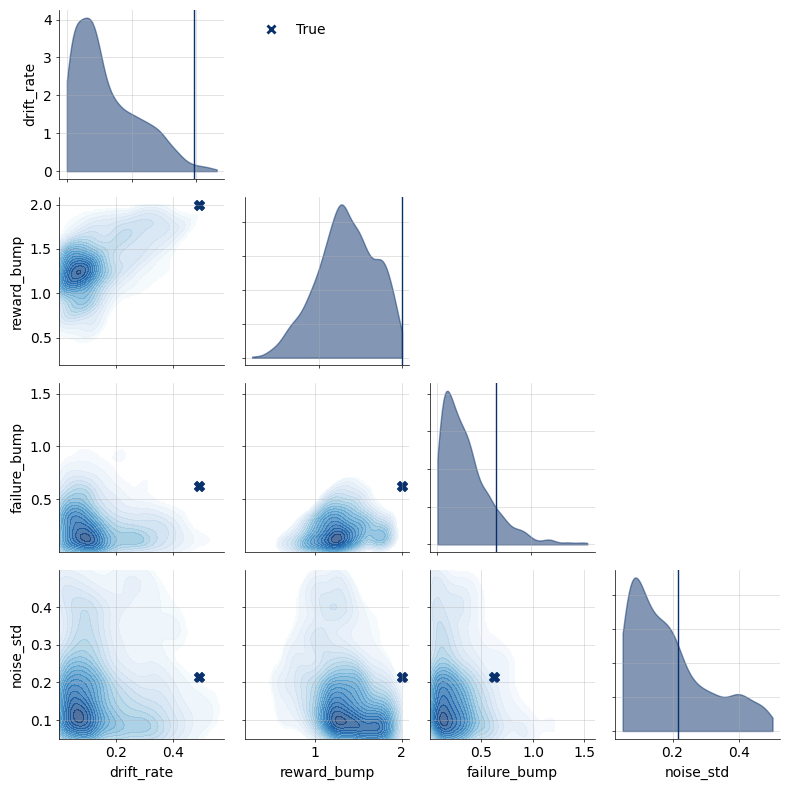

In [7]:
figsize_per_param=2.0
n_params = posterior_samples.shape[1]
fig, axes = plt.subplots(n_params, n_params, figsize=(figsize_per_param*n_params, figsize_per_param*n_params))
pairplot(posterior_samples, true_theta, param_names, figsize_per_param=figsize_per_param, fig=fig, axes=axes)

plt.tight_layout()
plt.show()


2. Simulating observed data...
   True theta: [0.33333334 0.29579496 1.7935901  0.45981896]

3. Testing inference...

Normalizing observed statistics...
Observed stats (raw): [0.52207667 1.         1.         1.4550257  0.         0.
 1.1637621  0.         0.         0.879911   1.         1.
 1.8525805  1.         1.         2.6726274  1.         1.
 3.496332   1.         1.         4.3449774  1.         1.
 5.3172984  0.         1.         7.2085085  0.         0.
 0.8827312  1.         1.         1.8106991  0.         1.
 2.6086178  0.         0.         1.2310042  1.         1.
 2.133311   1.         1.         3.051426   1.         1.
 3.980657   1.         1.         5.172019   0.         1.
 6.139593   0.         0.         0.8588338  1.         1.
 1.6893611  1.         1.         2.7477787  0.         1.
 3.635513   0.         0.         0.8185022  1.         1.
 1.7076594  1.         1.         2.70755    0.         1.
 3.56434    0.         0.         0.90745735 1.         1

/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmaps[color_i])(1.)
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(true_params[j], true_params[i], c=color, s=50, marker='X', label='True')
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA s

   True theta: [0.6666667  0.29579496 1.7935901  0.45981896]

3. Testing inference...

Normalizing observed statistics...
Observed stats (raw): [0.24310645 1.         1.         1.1221505  1.         1.
 2.2286887  0.         1.         3.1631012  0.         0.
 0.9484801  0.         0.         1.530303   0.         0.
 0.8388456  1.         1.         1.6629894  0.         1.
 2.6530726  0.         0.         0.9701545  0.         0.
 0.9867748  1.         1.         2.065785   0.         1.
 3.2151697  0.         0.         1.0944836  0.         0.
 1.015321   0.         0.         1.3310821  0.         1.
 2.2015896  0.         0.         0.85709953 1.         1.
 1.707387   1.         1.         2.605003   0.         0.
 0.9058241  0.         1.         1.883709   0.         0.
 0.8837617  1.         1.         1.8149538  1.         1.
 2.9774935  0.         0.         0.9327186  0.         1.
 2.125485   0.         0.         0.87347853 1.         1.
 1.7162654  1.         1.     

/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmaps[color_i])(1.)
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(true_params[j], true_params[i], c=color, s=50, marker='X', label='True')
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA s

   True theta: [1.         0.29579496 1.7935901  0.45981896]

3. Testing inference...

Normalizing observed statistics...
Observed stats (raw): [0.27425835 1.         1.         1.2794197  1.         1.
 2.7149873  1.         1.         3.7278638  0.         0.
 0.9056635  1.         1.         2.1174936  0.         0.
 0.87386876 1.         1.         1.7278637  1.         1.
 2.9303732  0.         0.         0.80443907 0.         1.
 1.6245813  0.         0.         1.1547582  1.         1.
 2.314147   0.         0.         0.88317156 1.         1.
 2.1594052  0.         0.         1.2183189  0.         0.
 1.1345003  0.         0.         1.4883773  0.         0.
 0.85252035 0.         0.         0.87700987 0.         0.
 0.89847827 0.         0.         0.81257194 1.         1.
 2.0219295  0.         0.         0.83280295 0.         0.
 0.87990093 1.         1.         2.3303456  0.         0.
 0.8331617  0.         0.         0.8156965  1.         1.
 2.0096183  0.         0.     

/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmaps[color_i])(1.)
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(true_params[j], true_params[i], c=color, s=50, marker='X', label='True')
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA s

   True theta: [1.3333334  0.29579496 1.7935901  0.45981896]

3. Testing inference...

Normalizing observed statistics...
Observed stats (raw): [0.49698165 1.         1.         1.5481837  0.         0.
 0.84237087 0.         0.         0.91964746 0.         0.
 1.3536093  0.         0.         1.0282068  0.         0.
 0.97529644 0.         0.         1.0668551  0.         0.
 0.8271735  0.         1.         1.644739   0.         0.
 0.9183848  0.         0.         1.2787998  0.         0.
 0.9275194  0.         0.         0.9054063  1.         1.
 1.7141575  0.         0.         0.86141783 1.         1.
 1.9179063  0.         0.         0.8746133  0.         0.
 1.1233597  0.         1.         2.227413   0.         0.
 0.8352793  0.         0.         0.86169827 0.         1.
 1.7795238  0.         0.         0.8979533  0.         0.
 0.8002585  0.         0.         0.8778338  1.         1.
 1.7509019  0.         0.         1.03836    0.         0.
 1.4757519  0.         0.     

/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmaps[color_i])(1.)
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(true_params[j], true_params[i], c=color, s=50, marker='X', label='True')
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA s

   True theta: [1.6666666  0.29579496 1.7935901  0.45981896]

3. Testing inference...

Normalizing observed statistics...
Observed stats (raw): [0.73953164 0.         1.         1.7768033  0.         0.
 0.9509976  0.         0.         1.1931419  0.         0.
 0.82291573 0.         0.         0.8748883  0.         0.
 0.8628422  0.         0.         0.8648243  0.         0.
 1.6863966  0.         0.         1.0015168  0.         0.
 1.0569824  0.         0.         1.7881279  0.         0.
 1.185682   0.         0.         0.8016937  0.         0.
 0.8662044  0.         0.         0.8780998  1.         1.
 1.9469334  0.         0.         1.1661947  0.         0.
 0.875245   0.         0.         0.8880474  0.         0.
 1.2856562  0.         0.         0.8716915  0.         0.
 0.9341044  0.         0.         1.5954068  0.         0.
 0.9796163  0.         0.         0.8848978  0.         0.
 0.95191664 0.         0.         0.8087574  0.         0.
 0.8826748  1.         1.     

/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap(cmaps[color_i])(1.)
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(true_params[j], true_params[i], c=color, s=50, marker='X', label='True')
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_70034/3513336251.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA s

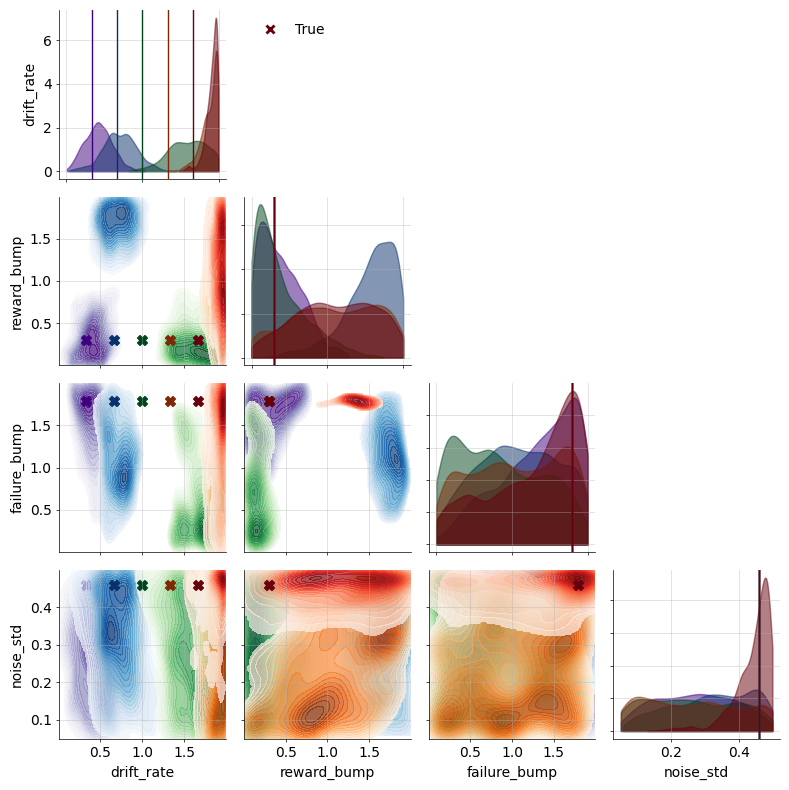

In [8]:
vary_theta = 0
number_of_samples = 5
param_names = ["drift_rate", "reward_bump", "failure_bump", "noise_std"]
param_labels = [
    "drift_rate: evidence accumulation rate",
    "reward_bump: evidence boost from receiving reward",
    "failure_bump: evidence boost from not receiving reward",
    "noise_std: std of noise in evidence accumulation"
]

cmap = mpl.colormaps['rainbow']
# 3. Sample the colormap at regular intervals from 0 to 1
# This returns an array of RGBA tuples
gradient = np.linspace(0, 1, number_of_samples+2)[1:-1]
colors_rgba = cmap(gradient)
theta_values = np.linspace(saved_data['config']['prior_low'][vary_theta], 
                           saved_data['config']['prior_high'][vary_theta], 
                           number_of_samples+2)[1:-1]

figsize_per_param=2.0
n_params = posterior_samples.shape[1]
fig, axes = plt.subplots(n_params, n_params, figsize=(figsize_per_param*n_params, figsize_per_param*n_params))

# --- Simulate observed data ---
print("\n2. Simulating observed data...")
rng_key = random.PRNGKey(666)
rng_key, subkey = random.split(rng_key)
true_theta = prior_fn().sample(seed=subkey)['theta']

for theta_i, theta in enumerate(theta_values):
    true_theta = true_theta.at[vary_theta].set(theta)
    rng_key, subkey = random.split(rng_key)
    _, observed_stats = simulator.simulate_one_window(true_theta, subkey)
    print(f"   True theta: {true_theta}")

    # --- Run inference ---
    print("\n3. Testing inference...")
    rng_key, subkey = random.split(rng_key)
    posterior_samples, diagnostics = infer_parameters_snle(
    snle,
    saved_data['snle_params'],
    observed_stats, 
    saved_data['y_mean'], saved_data['y_std'],
    num_samples=1000,
    num_warmup=50,
    num_chains=2,
    rng_key=subkey
    )

    # --- Plot posterior distributions ---
    pairplot(posterior_samples, true_theta, param_names, 
             figsize_per_param=figsize_per_param, fig=fig, axes=axes, 
             color_i=theta_i)


plt.tight_layout()
plt.show()